## EIT Parser Validation

Verifica che `DragerEitParser` legga correttamente i file `.eit` e che la calibrazione produca valori sensati.

Pipeline di calibrazione (costanti EIDORS, A. Adler 2016 — hardcoded, non nell'header):
- `vv = FT_A * trans_A - FT_B * trans_B`  → transimpedenza calibrata [Ω]
- `I_real = injection_current / FC_CURRENT` → corrente reale iniettata [A]
- `V_diff = (voltage_A - voltage_B) / FV_VOLTAGE` → tensione differenziale [V]

Confronto con il file `.bin` corrispondente per validazione incrociata.

In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fasteit.parsers.draeger.eit.eit_parser import DragerEitParser
from fasteit.parsers.draeger.bin.bin_parser import DragerBinParser

In [10]:
EIT_FILE = Path("../src/fasteit/test_files/patient01.eit")
BIN_FILE = Path("../src/fasteit/test_files/patient01.bin")

eit = DragerEitParser().parse(EIT_FILE)
bin_ = DragerBinParser().parse(BIN_FILE)

## 1. Struttura del risultato

In [11]:
from fasteit.parsers.draeger.eit.eit_utils import FT_A, FT_B, FC_CURRENT, FV_VOLTAGE

print("=== .eit parser output ===")
print(f"measurements (vv) shape : {eit.measurements.shape}")
print(f"fs                      : {eit.fs} Hz")
print(f"n_frames                : {eit.metadata['n_frames']}")
print(f"n_electrodes            : {eit.metadata['n_electrodes']}")
print(f"n_measurements          : {eit.metadata['n_measurements']}")
print(f"detected_spec           : {eit.metadata['detected_spec']}")
print(f"date / time             : {eit.metadata.get('date')} {eit.metadata.get('time')}")
print(f"frequency               : {eit.metadata.get('frequency_khz')} kHz")
print(f"amplitude               : {eit.metadata.get('amplitude_ua')} µA")
print()
print("calibration constants (EIDORS hardcoded, A. Adler 2016):")
print(f"  FT_A={FT_A}, FT_B={FT_B}, FC_CURRENT={FC_CURRENT}, FV_VOLTAGE={FV_VOLTAGE}")
print()
print("aux_signals keys:", list(eit.aux_signals.keys()))

=== .eit parser output ===
measurements (vv) shape : (11500, 208)
fs                      : 50.0 Hz
n_frames                : 11500
n_electrodes            : 16
n_measurements          : 208
detected_spec           : Draeger_EIT_v51
date / time             : 04.01.2024 18:10:54.015
frequency               : 101.501 kHz
amplitude               : 9100.0 µA

calibration constants (EIDORS hardcoded, A. Adler 2016):
  FT_A=0.00098242, FT_B=0.00019607, FC_CURRENT=194326.3536, FV_VOLTAGE=0.11771

aux_signals keys: ['timestamp', 'trans_A', 'trans_B', 'injection_current', 'I_real', 'voltage_A', 'voltage_B', 'V_diff', 'frame_counter', 'medibus']


## 2. Sanity check: vv non è zero, non ha NaN

In [12]:
vv = eit.measurements

print(f"NaN count : {np.isnan(vv).sum()}")
print(f"Zero rows : {(vv == 0).all(axis=1).sum()}")
print(f"min / max : {vv.min():.4f} / {vv.max():.4f}")
print(f"mean      : {vv.mean():.4f}")

NaN count : 0
Zero rows : 0
min / max : -0.0000 / 0.1597
mean      : 0.0125


## 3. Timestamps monotoni

In [13]:
ts = eit.aux_signals["timestamp"]
print(f"Timestamp range : {ts.min():.6f} – {ts.max():.6f} (fraction of day)")
print(f"Monotonically increasing: {bool(np.all(np.diff(ts) >= 0))}")
print(f"Duration approx : {(ts.max() - ts.min()) * 24 * 60:.1f} min")

Timestamp range : 0.757570 – 0.760232 (fraction of day)
Monotonically increasing: True
Duration approx : 3.8 min


## 4. Waveform vv — primo elettrodo, primi 500 frame

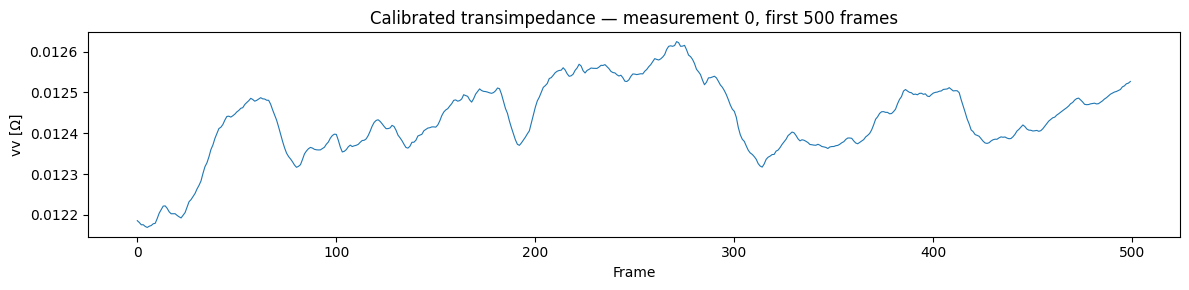

In [14]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(vv[:500, 0], lw=0.8)
ax.set_xlabel("Frame")
ax.set_ylabel("vv [Ω]")
ax.set_title("Calibrated transimpedance — measurement 0, first 500 frames")
plt.tight_layout()
plt.show()

## 5. Confronto frame count: .eit vs .bin

In [ ]:
print(f".eit n_frames : {eit.metadata['n_frames']}")
print(f".bin n_frames : {bin_.n_frames}")
print(f".eit fs       : {eit.fs} Hz")
print(f".bin fs       : {bin_.fs} Hz")

delta = abs(eit.metadata['n_frames'] - bin_.n_frames)

.eit n_frames : 11500
.bin n_frames : 11500
.eit fs       : 50.0 Hz
.bin fs       : 50.0 Hz

Frame count difference: 0 (0.0 s)
